 CARGANDO METADATOS Y FILTRANDO SUBTIPOS DE TOS (EXCLUYENDO NULLS)

📊 Resumen de conteo de subtipos de tos (excluyendo no-toses):
   • DRY     :   1776 muestras (63.09%)
   • WET     :    532 muestras (18.90%)
   • UNKNOWN :    507 muestras (18.01%)

 Total de muestras de TOS analizadas: 2815


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9036\2056307495.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


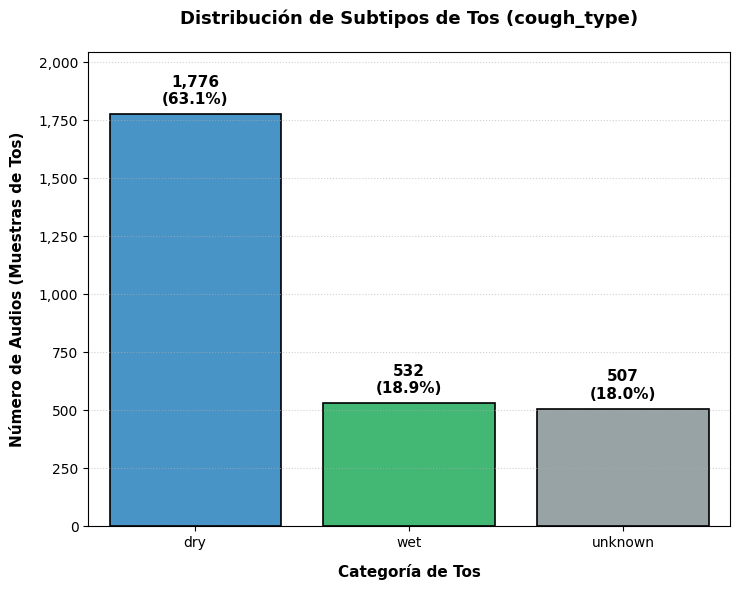


✅ Gráfica guardada exitosamente en:
 C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\graphs_results_experiment_multiclasification\cough_type_distribution.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 📂 FASE 1: CARGA DE METADATOS
# =====================================================================
PATH_CSV = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\combined_metadata_datasets.csv"
PATH_OUTPUT_GRAPHS = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\graphs_results_experiment_multiclasification"
os.makedirs(PATH_OUTPUT_GRAPHS, exist_ok=True)

print("=" * 70)
print(" CARGANDO METADATOS Y FILTRANDO SUBTIPOS DE TOS (EXCLUYENDO NULLS)")
print("=" * 70)

# Cargar el dataset consolidado
df = pd.read_csv(PATH_CSV)

# Verificar si la columna existe en el CSV
if 'cough_type' not in df.columns:
    raise ValueError("⚠️ La columna 'cough_type' no se encuentra en el CSV especificado.")

# 1. FILTRADO CRUCIAL: Eliminar valores nulos (controles/no-tos)
df_cough = df.dropna(subset=['cough_type']).copy()

# 2. Limpieza de texto (minúsculas y sin espacios adicionales)
df_cough['cough_type'] = df_cough['cough_type'].astype(str).str.lower().str.strip()

# 3. Filtrar explícitamente solo por las tres categorías requeridas: dry, wet, unknown
df_cough = df_cough[df_cough['cough_type'].isin(['dry', 'wet', 'unknown'])]

# Conteo absoluto de cada categoría de tos
cough_counts = df_cough['cough_type'].value_counts()

total_cough_samples = len(df_cough)

print("\n📊 Resumen de conteo de subtipos de tos (excluyendo no-toses):")
for cat, count in cough_counts.items():
    pct = (count / total_cough_samples) * 100
    print(f"   • {cat.upper():<8}: {count:>6} muestras ({pct:.2f}%)")

print(f"\n Total de muestras de TOS analizadas: {total_cough_samples}")

# =====================================================================
# 📊 FASE 2: GENERACIÓN DE LA GRÁFICA DE BARRAS
# =====================================================================
plt.figure(figsize=(7.5, 6))

# Paleta de colores diferenciada
palette = {'dry': '#3498db', 'wet': '#2ecc71', 'unknown': '#95a5a6'}
colors = [palette.get(cat, '#e74c3c') for cat in cough_counts.index]

ax = sns.barplot(
    x=cough_counts.index, 
    y=cough_counts.values, 
    palette=colors,
    edgecolor="black",
    linewidth=1.2
)

# Añadir etiquetas con valor absoluto y porcentaje relativo SOBRE LAS TOSES
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_cough_samples) * 100
    ax.annotate(
        f'{int(height):,}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

# Formato visual profesional
plt.title("Distribución de Subtipos de Tos (cough_type)", fontsize=13, fontweight="bold", pad=20)
plt.xlabel("Categoría de Tos", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Número de Audios (Muestras de Tos)", fontsize=11, fontweight="bold", labelpad=10)

# Formatear eje Y con separadores de miles y espacio para el texto de las barras
ax.yaxis.set_major_formatter('{x:,.0f}')
plt.ylim(0, max(cough_counts.values) * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

# Guardar figura a 300 DPI
path_save_graph = os.path.join(PATH_OUTPUT_GRAPHS, "cough_type_distribution.png")
plt.savefig(path_save_graph, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print(f"✅ Gráfica guardada exitosamente en:\n {path_save_graph}")
print("=" * 70)